In [1]:
import pandas as pd
from SCPIntModel import *

In [2]:
import scanpy as sc

In [3]:
multibatch_ann = sc.read_h5ad('../data/task_data/frozen_fresh_ann.h5ad')

In [4]:
multibatch_ann

AnnData object with n_obs × n_vars = 2339 × 1223
    obs: 'celltype', 'batch'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [5]:
processor = AnnDataProcessor(multibatch_ann, batch_key="batch")

Loaded 2339 cells × 1223 proteins
Batches (2): ['fresh', 'frozen']


In [6]:
loader  = processor.make_dataloader(batch_size=128)

In [7]:
 # 构建模型
model = scProteoIntegrator(
    n_genes   = processor.n_genes,
    n_batches = processor.n_batches,
)

In [8]:
lambda_cls=0.1
lambda_adv=0.4
lambda_mse=1
lr = 0.01
epochs = 1000
warmup = 1
md = 'frozen_fresh'

In [9]:
trainer = Trainer(model, lr=lr, lambda_cls=lambda_cls, lambda_adv=lambda_adv,lambda_mse=lambda_mse, lr_reduc_factor=0.9)

In [10]:
trainer.fit(loader, n_epochs=epochs, adv_warmup_epochs=warmup)

Epoch   10 | total=2.5781 | recon=1.2877 | mse=0.8111 | cls=0.0111 | adv=1.1953 |lr=0.01
Epoch   20 | total=2.6512 | recon=1.2931 | mse=0.8180 | cls=0.0239 | adv=1.3444 |lr=0.009000000000000001
Epoch   30 | total=3.7231 | recon=1.2711 | mse=0.7956 | cls=0.0116 | adv=4.1383 |lr=0.007290000000000001
Epoch   40 | total=3.8996 | recon=1.2681 | mse=0.7909 | cls=0.0094 | adv=4.5992 |lr=0.005904900000000002
Epoch   50 | total=2.3743 | recon=1.2808 | mse=0.7986 | cls=0.0405 | adv=0.7270 |lr=0.005314410000000002
Epoch   60 | total=3.8036 | recon=1.2371 | mse=0.7582 | cls=0.0243 | adv=4.5145 |lr=0.004782969000000002
Epoch   70 | total=2.7322 | recon=1.2308 | mse=0.7535 | cls=0.0055 | adv=1.8686 |lr=0.004304672100000002
Epoch   80 | total=2.5619 | recon=1.2252 | mse=0.7484 | cls=0.0040 | adv=1.4698 |lr=0.003486784401000002
Epoch   90 | total=2.4974 | recon=1.2228 | mse=0.7458 | cls=0.0053 | adv=1.3205 |lr=0.0028242953648100018
Epoch  100 | total=2.3685 | recon=1.2143 | mse=0.7384 | cls=0.0018 | a

In [11]:
model_name = f"{md}_cls-{lambda_cls}_adv-{lambda_adv}_mse-{lambda_mse}_warmup-{warmup}_lr-{lr}_epoch-{epochs}"

损失曲线已保存至: ../data/model/frozen_fresh_cls-0.1_adv-0.4_mse-1_warmup-1_lr-0.01_epoch-1000.svg


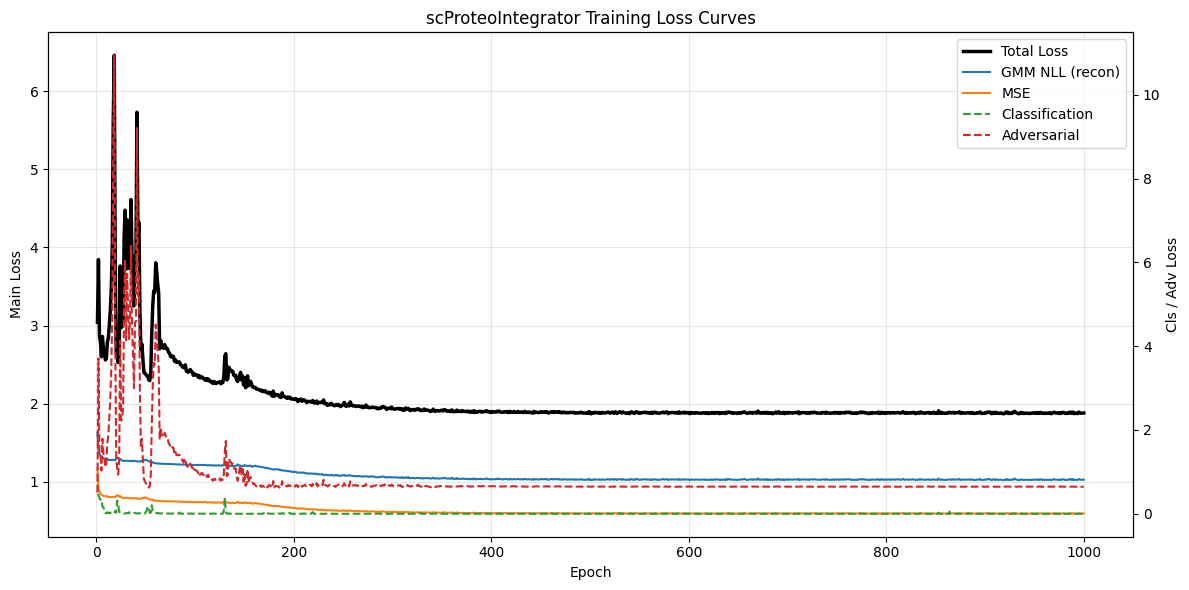

In [12]:
trainer.plot_losses(
    save_path=f"../data/model/{model_name}.svg",   # 可改成任意路径
    show=True                      # False 则只保存不弹窗
)

In [13]:
trainer.save(f"../data/model/{model_name}.pt")

Model saved to ../data/model/frozen_fresh_cls-0.1_adv-0.4_mse-1_warmup-1_lr-0.01_epoch-1000.pt
